# Offline SIR / SEIR / SIS ensemble comparison

 Compare predefined and explicitly constructed epydemix models with independent
 binomial reference implementations. This is a visual model check, not a posterior
 correctness oracle: exact simulation draws need not agree across implementations.
 All random draws receive explicit seeds. The same epydemix ensemble must agree
 exactly between sequential and two-worker spawn execution. Requires the separate
 simulation integration PR; no population download or optional pyabc dependency.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import multiprocessing as mp

import matplotlib.pyplot as plt
import numpy as np
from models.stochastic_seir import StochasticSEIR
from models.stochastic_sir import StochasticSIR
from models.stochastic_sis import StochasticSIS

from epydemix import EpiModel
from epydemix.model.predefined_models import create_seir, create_sir, create_sis
from epydemix.population import Population

mp.set_start_method("spawn", force=True)
SEED, NSIM, WORKERS = 43, 32, 2
START, END = "2023-01-01", "2023-02-09"

population = Population()
population.add_population([10000])
population.add_contact_matrix([[1.0]])
specifications = [
    ("SIR", create_sir(0.3, 0.1), StochasticSIR(9900, 100, 0, 0.3, 0.1, 10000, 40)),
    (
        "SEIR",
        create_seir(0.3, 0.2, 0.1),
        StochasticSEIR(9850, 50, 100, 0, 0.3, 0.2, 0.1, 10000, 40),
    ),
    ("SIS", create_sis(0.3, 0.1), StochasticSIS(9900, 100, 0.3, 0.1, 10000, 40)),
]

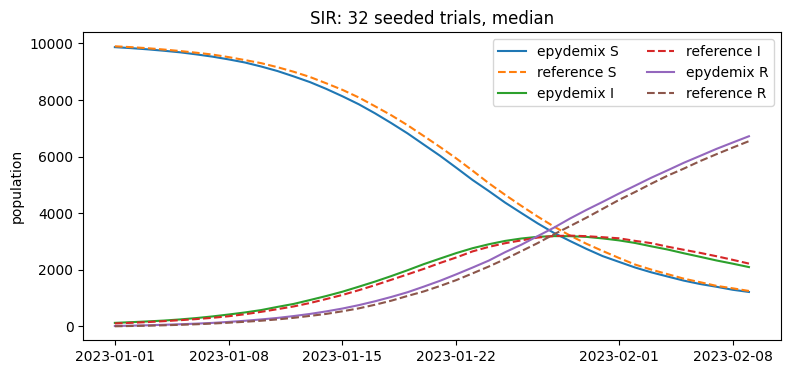

SIR sequential = parallel = custom; full grid 40


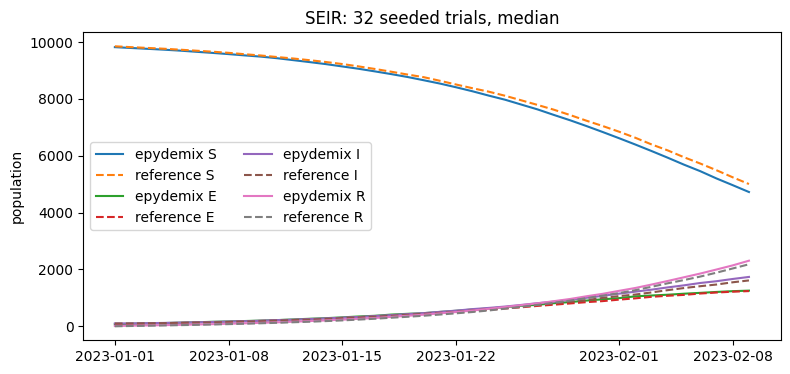

SEIR sequential = parallel = custom; full grid 40


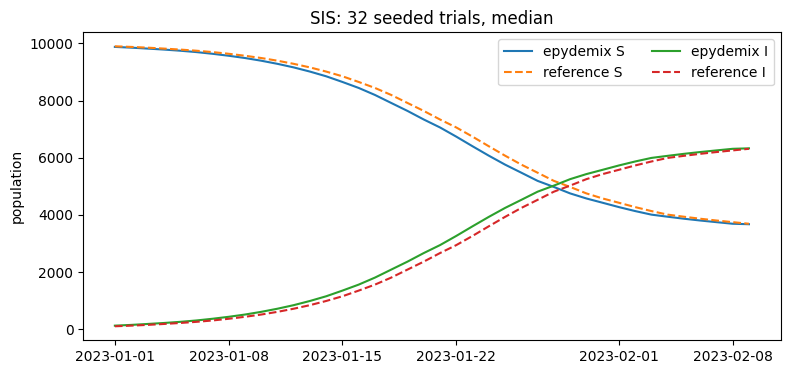

SIS sequential = parallel = custom; full grid 40


In [3]:
for name, predefined, reference in specifications:
    predefined.set_population(population)
    custom = EpiModel(
        compartments=list(predefined.compartments),
        parameters={
            "transmission_rate": 0.3,
            "recovery_rate": 0.1,
            "incubation_rate": 0.2,
        },
    )
    for transition in predefined.transitions_list:
        custom.add_transition(
            transition.source,
            transition.target,
            kind=transition.kind,
            params=transition.params,
        )
    custom.set_population(population)
    initial = {
        "Susceptible": np.array([9850 if name == "SEIR" else 9900]),
        "Infected": np.array([100]),
    }
    if name != "SIS":
        initial["Recovered"] = np.array([0])
    if name == "SEIR":
        initial["Exposed"] = np.array([50])
    options = dict(
        start_date=START,
        end_date=END,
        initial_conditions_dict=initial,
        Nsim=NSIM,
        rng=SEED,
    )
    sequential = predefined.run_simulations(**options)
    parallel = predefined.run_simulations(**options, n_workers=WORKERS)
    explicit = custom.run_simulations(**options, n_workers=WORKERS)
    for key, values in sequential.get_stacked_compartments().items():
        np.testing.assert_array_equal(values, parallel.get_stacked_compartments()[key])
        np.testing.assert_array_equal(values, explicit.get_stacked_compartments()[key])
    reference_quantiles = reference.run_simulations(NSIM, quantiles=(0.5,), rng=SEED)
    median = parallel.get_quantiles_compartments(quantiles=[0.5])
    fig, ax = plt.subplots(figsize=(9, 4))
    for short, compartment in zip(
        "SEIR" if name == "SEIR" else "SIR" if name == "SIR" else "SI",
        predefined.compartments,
    ):
        ax.plot(
            median["date"], median[f"{compartment}_total"], label=f"epydemix {short}"
        )
        ax.plot(
            median["date"],
            reference_quantiles[short][0.5],
            linestyle="--",
            label=f"reference {short}",
        )
    ax.set(title=f"{name}: {NSIM} seeded trials, median", ylabel="population")
    ax.legend(ncol=2)
    plt.show()
    plt.close(fig)
    print(name, "sequential = parallel = custom; full grid", len(median))